# Business Understanding

#### About Dataset
This dataset contains 5,000 customer-level financial and behavioral attributes designed to support credit risk modeling and Explainable AI (XAI) research. It includes demographic variables, banking activity patterns, debit card usage, digital banking interactions, credit history, loan behavior, and indicators of fraud or past default. The target variable (credit_risk) classifies each customer as low-risk or high-risk based on financial behavior, credit score, payment history, and flagged risk signals.

**customer_id:-** Unique identifier for each customer.  
  
**age:-** Customer age in years.  
  
**gender:-** Customer gender (Male, Female, Other).  
  
**employment_status:-** Employment type: Employed, Self-Employed, Unemployed.  
  
**annual_income:-** Yearly income level.  
  
**account_age_months:-** Number of months the bank account has been active.   
  
**avg_monthly_balance:-** Average monthly account balance.  
  
**num_deposits_per_month:-** How many deposits the customer makes monthly.  
  
**avg_deposit_amount:-** Average value of deposits.  
  
**debit_card_usage_frequency:-** Total debit card transaction count per month.  
    
**debit_card_spending:-** Monthly spending through debit card transactions.  
  
**mobile_banking_logins:-** Number of times customer logs into mobile banking.  
  
**online_transfer_frequency:-** Number of online fund transfers per month.  
  
**atm_withdrawal_frequency:-** ATM withdrawals per month.  
  
**credit_score:-** Credit rating (300–900 scale).  
  
**num_open_loans:-** How many active loans the customer currently holds.  
  
**total_outstanding_debt:-** Total amount of unpaid debt.  
     
**late_payment_count:-** Number of late loan payments recorded.  
  
**loan_default_history:-**  
Binary flag:   
1 = customer previously defaulted  
0 = no default history  
  
**fraud_flag:-** Binary indicator of suspected or confirmed fraud.  
  
**loan_application_amount:-** Amount of loan applied for.  

**credit_risk (Target Variable):-**   
Risk classification:  
0 = Low risk  
1 = High risk  

# Data Ingestion

In [78]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [79]:
df = pd.read_csv("D:/Data Analytics/Work/Data Science/ML/Credit Risk/data/credit_risk_dataset.csv")
df.head()

,customer_id,age,gender,employment_status,annual_income,account_age_months,avg_monthly_balance,num_deposits_per_month,avg_deposit_amount,debit_card_usage_frequency,...,online_transfer_frequency,atm_withdrawal_frequency,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_default_history,fraud_flag,loan_application_amount,credit_risk
0,CUST_00000,58,Male,Unemployed,58137.751192,115,524.679407,1,171.342369,49,...,16,1,539,5,14435.423445,2,0,0,15510.576882,1
1,CUST_00001,48,Male,Self-Employed,26174.922827,32,2635.203357,1,985.607164,1,...,1,2,494,5,11263.099341,2,0,0,14819.436498,1
2,CUST_00002,34,Other,Unemployed,75566.837265,14,2334.341061,9,994.310119,42,...,5,6,437,3,15017.144132,5,0,0,10909.806507,1
3,CUST_00003,62,Male,Self-Employed,35197.961516,179,2425.384332,10,366.115346,4,...,7,7,809,1,12626.138476,2,0,0,500.000000,0
4,CUST_00004,27,Female,Self-Employed,12136.998349,225,10.000000,8,786.752258,16,...,16,3,522,1,13576.704320,4,0,0,9514.591618,1


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 5000 non-null   object 
 1   age                         5000 non-null   int64  
 2   gender                      5000 non-null   object 
 3   employment_status           5000 non-null   object 
 4   annual_income               5000 non-null   float64
 5   account_age_months          5000 non-null   int64  
 6   avg_monthly_balance         5000 non-null   float64
 7   num_deposits_per_month      5000 non-null   int64  
 8   avg_deposit_amount          5000 non-null   float64
 9   debit_card_usage_frequency  5000 non-null   int64  
 10  debit_card_spending         5000 non-null   float64
 11  mobile_banking_logins       5000 non-null   int64  
 12  online_transfer_frequency   5000 non-null   int64  
 13  atm_withdrawal_frequency    5000 

In [81]:
df.shape

(5000, 22)

# Data Understanding

In [82]:
# Check nulls
df.isnull().sum()

customer_id                   0
age                           0
gender                        0
employment_status             0
annual_income                 0
account_age_months            0
avg_monthly_balance           0
num_deposits_per_month        0
avg_deposit_amount            0
debit_card_usage_frequency    0
debit_card_spending           0
mobile_banking_logins         0
online_transfer_frequency     0
atm_withdrawal_frequency      0
credit_score                  0
num_open_loans                0
total_outstanding_debt        0
late_payment_count            0
loan_default_history          0
fraud_flag                    0
loan_application_amount       0
credit_risk                   0
dtype: int64

In [83]:
# Check for Duplicates
df[df.duplicated]

,customer_id,age,gender,employment_status,annual_income,account_age_months,avg_monthly_balance,num_deposits_per_month,avg_deposit_amount,debit_card_usage_frequency,...,online_transfer_frequency,atm_withdrawal_frequency,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_default_history,fraud_flag,loan_application_amount,credit_risk


In [84]:
numerical = df.select_dtypes(include=['int64','float64']).columns
categorical = df.select_dtypes(include=['object']).columns

print(f"\nNumerical({len(numerical)}):\n{numerical}")
print(f"\nCategorical({len(categorical)}):\n{categorical}")


Numerical(19):
Index(['age', 'annual_income', 'account_age_months', 'avg_monthly_balance',
       'num_deposits_per_month', 'avg_deposit_amount',
       'debit_card_usage_frequency', 'debit_card_spending',
       'mobile_banking_logins', 'online_transfer_frequency',
       'atm_withdrawal_frequency', 'credit_score', 'num_open_loans',
       'total_outstanding_debt', 'late_payment_count', 'loan_default_history',
       'fraud_flag', 'loan_application_amount', 'credit_risk'],
      dtype='object')

Categorical(3):
Index(['customer_id', 'gender', 'employment_status'], dtype='object')


# EDA

Target: 
credit_risk
1    3829
0    1171
Name: count, dtype: int64


<Axes: xlabel='credit_risk', ylabel='count'>

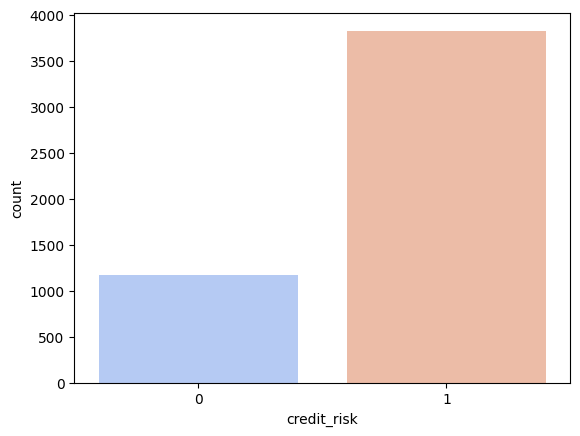

In [85]:
# Target Variable Distribution
print(f"Target: \n{df.credit_risk.value_counts()}")
sns.countplot(df,x='credit_risk',palette='coolwarm')

In [86]:
# Statistical Analysis of the NUmerical Variables
df.describe()

,age,annual_income,account_age_months,avg_monthly_balance,num_deposits_per_month,avg_deposit_amount,debit_card_usage_frequency,debit_card_spending,mobile_banking_logins,online_transfer_frequency,atm_withdrawal_frequency,credit_score,num_open_loans,total_outstanding_debt,late_payment_count,loan_default_history,fraud_flag,loan_application_amount,credit_risk
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.00000
mean,44.666600,49870.073961,121.226800,1500.912691,5.542000,800.663464,24.424800,500.284845,39.028000,9.660600,4.55720,599.328200,2.480800,12173.548537,3.46940,0.097400,0.028600,8149.415730,0.76580
std,14.384312,17831.984829,68.325584,772.243462,3.424118,341.229714,14.395172,245.167842,23.039457,5.858248,2.89109,174.345499,1.698649,5993.358818,2.29332,0.296531,0.166696,4309.579471,0.42354
min,20.000000,10000.000000,3.000000,10.000000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.00000,300.000000,0.000000,0.000000,0.00000,0.000000,0.000000,500.000000,0.00000
25%,32.000000,37633.483896,62.000000,958.522753,3.000000,559.312932,12.000000,328.342032,19.000000,4.000000,2.00000,447.000000,1.000000,8076.729416,1.00000,0.000000,0.000000,4993.481978,1.00000
50%,45.000000,49682.456590,120.500000,1486.067085,6.000000,802.695763,25.000000,498.752458,39.000000,10.000000,5.00000,597.000000,2.000000,12196.804292,3.00000,0.000000,0.000000,8039.116433,1.00000
75%,57.000000,61964.226233,181.000000,2024.758900,9.000000,1033.796072,37.000000,664.056885,58.000000,15.000000,7.00000,753.000000,4.000000,16279.963090,5.00000,0.000000,0.000000,11160.811371,1.00000
max,69.000000,113793.170197,239.000000,4818.316040,11.000000,1925.380969,49.000000,1379.491843,79.000000,19.000000,9.00000,899.000000,5.000000,32433.862750,7.00000,1.000000,1.000000,25622.344659,1.00000


In [87]:
# Categorical data values and counts
# Avoiding customer id in value counts as the id will be a unique value
for col in categorical:
    if(col != 'customer_id'):
        print(f"\n{col} (nunique:{df[col].nunique()})")
        print(df[col].value_counts())
    else:
        print("\nTotal Customer Count:",df[col].nunique())


Total Customer Count: 5000

gender (nunique:3)
gender
Female    1705
Other     1680
Male      1615
Name: count, dtype: int64

employment_status (nunique:3)
employment_status
Employed         1746
Self-Employed    1633
Unemployed       1621
Name: count, dtype: int64


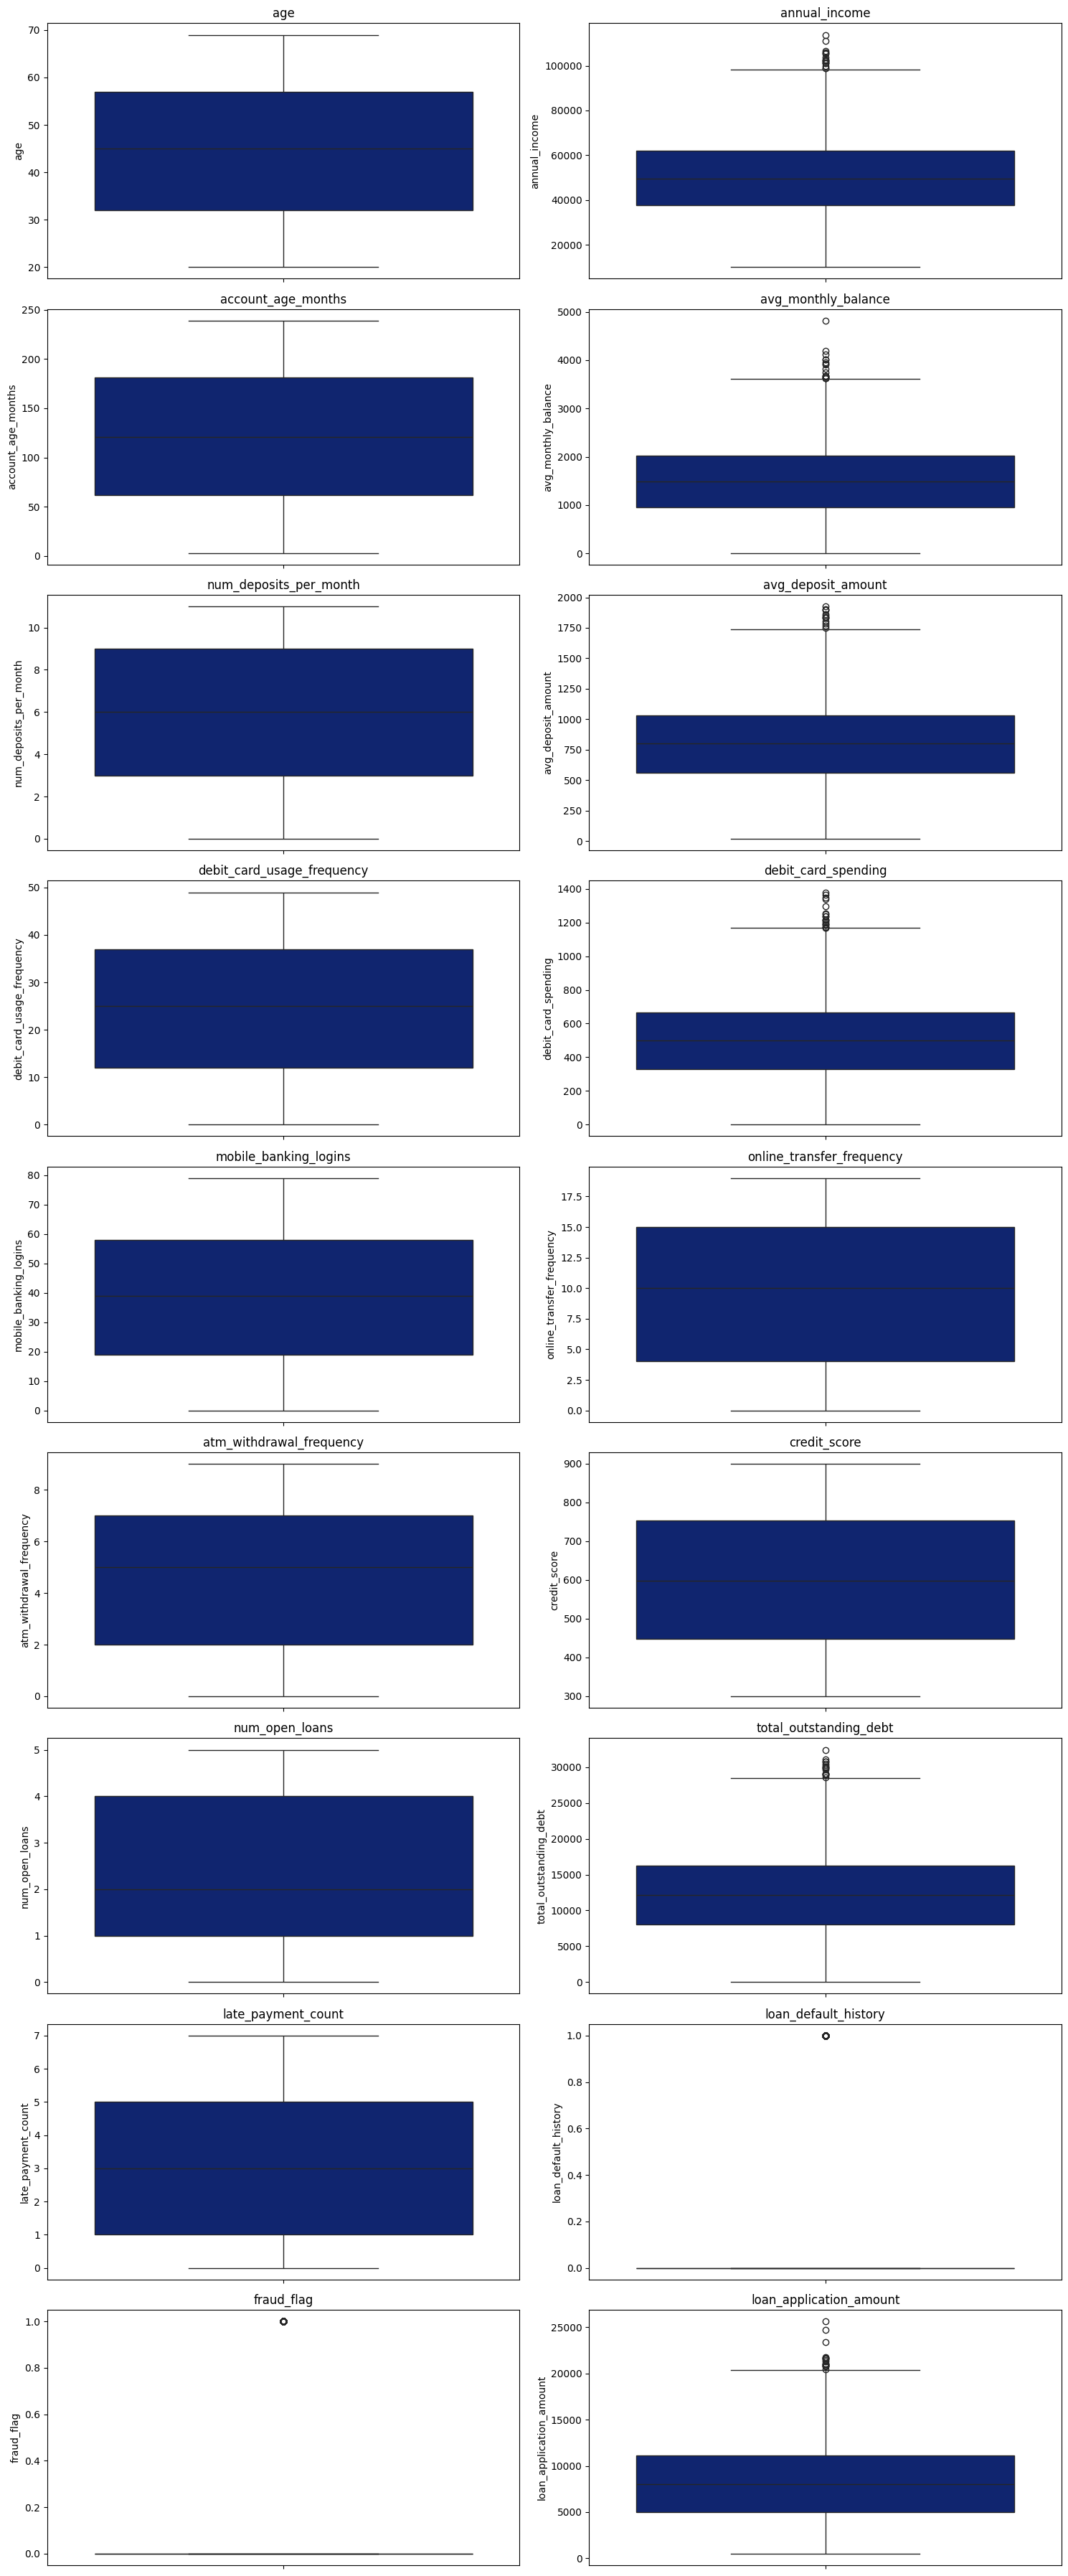

In [88]:
# Visual Distribution of box plots of numerical Variables excluding the target variable ( seeing if outliers present in data)

num = list(numerical)
for i,col in enumerate(num):
    if(col == 'credit_risk'):
        num.pop(i)
subplot_count = len(num)
rows = (subplot_count + 1) // 2
col = 2

fig,axes = plt.subplots(rows,col,figsize=(15,rows*4))
axes = axes.flatten()

for i,col in enumerate(num):
    sns.boxplot(
        df[col],
        palette='dark',
        ax=axes[i]
    ) 
    axes[i].set_title(col)

# Remove extra empty plots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
    

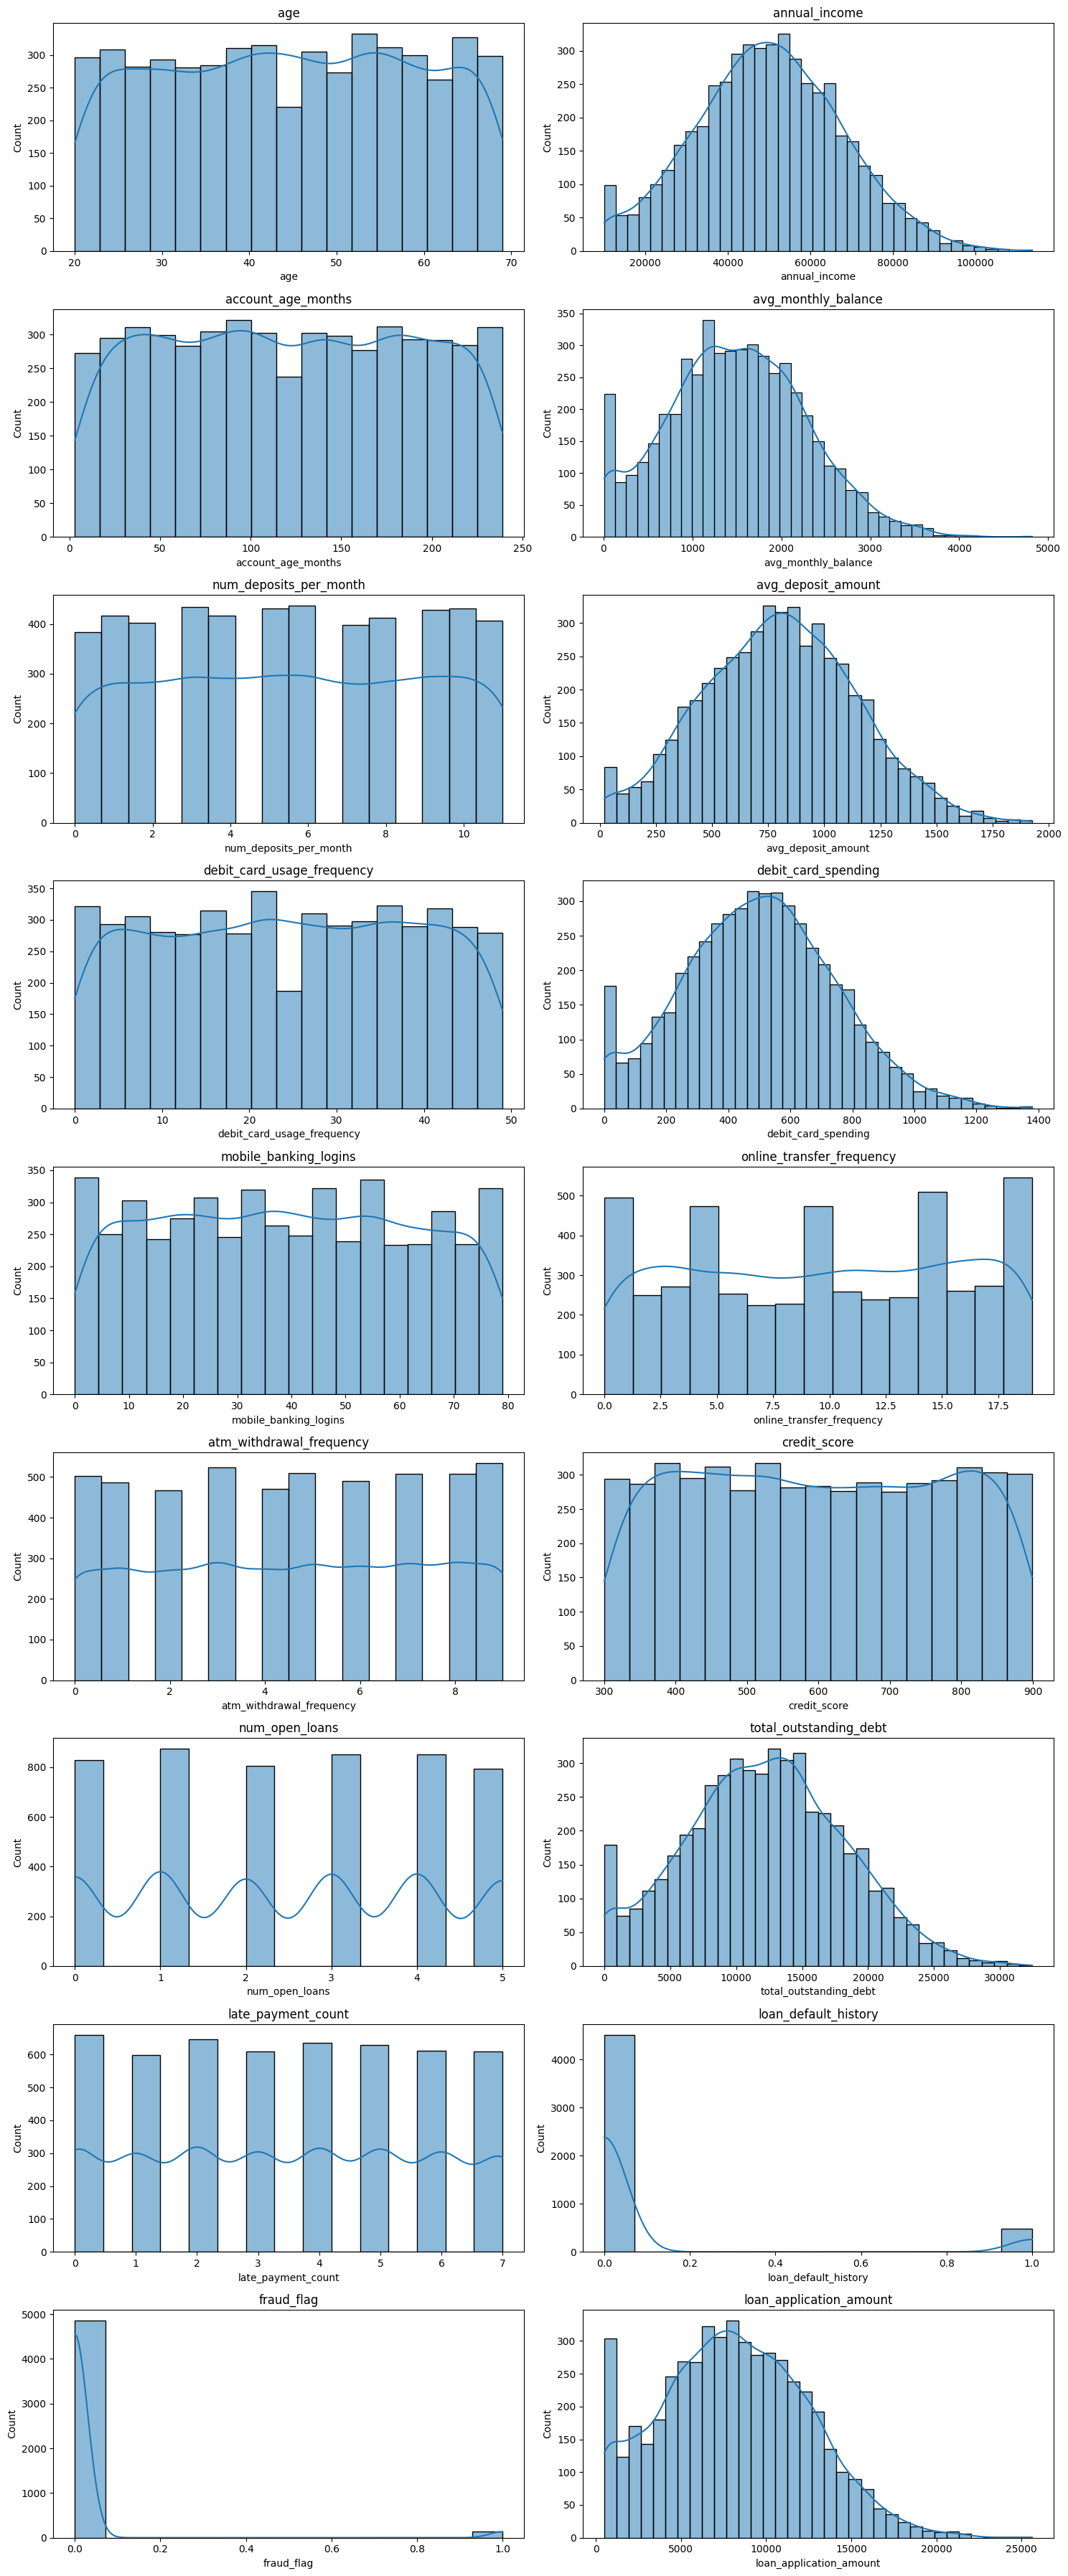

In [89]:
# Visual Distribution of numerical Variables excluding the target variable

num = list(numerical)
for i,col in enumerate(num):
    if(col == 'credit_risk'):
        num.pop(i)
subplot_count = len(num)
rows = (subplot_count + 1) // 2
col = 2

fig,axes = plt.subplots(rows,col,figsize=(15,rows*4))
axes = axes.flatten()

for i,col in enumerate(num):
    sns.histplot(
        df[col],
        palette='dark',
        ax=axes[i],
        kde=True
    ) 
    axes[i].set_title(col)

# Remove extra empty plots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
    

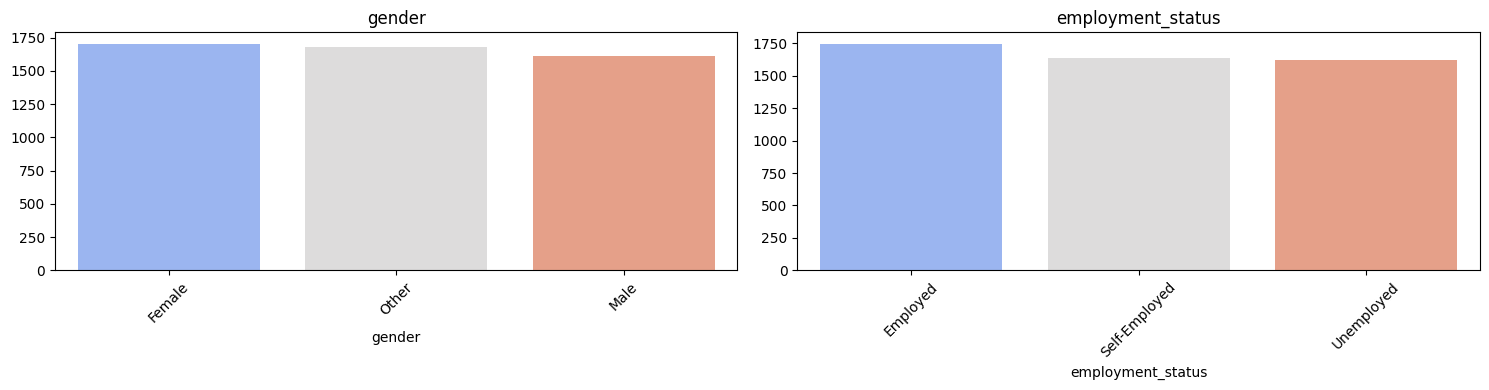

In [90]:
# Distribution of categorical data excluding customer id
cat = list(categorical)
for i,col in enumerate(cat):
    if(col == 'customer_id'):
        cat.pop(i)
subplot_count = len(cat)
rows = (subplot_count + 1) // 2
col = 2

fig,axes = plt.subplots(rows,col,figsize=(15,rows*4))
axes = axes.flatten()

for i,col in enumerate(cat):
    value_counts = df[col].value_counts()
    sns.barplot(
        hue=value_counts.index,
        x=value_counts.index,
        y=value_counts.values,
        ax=axes[i],
        palette="coolwarm",
        legend=False
    ) 
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

# Remove extra empty plots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

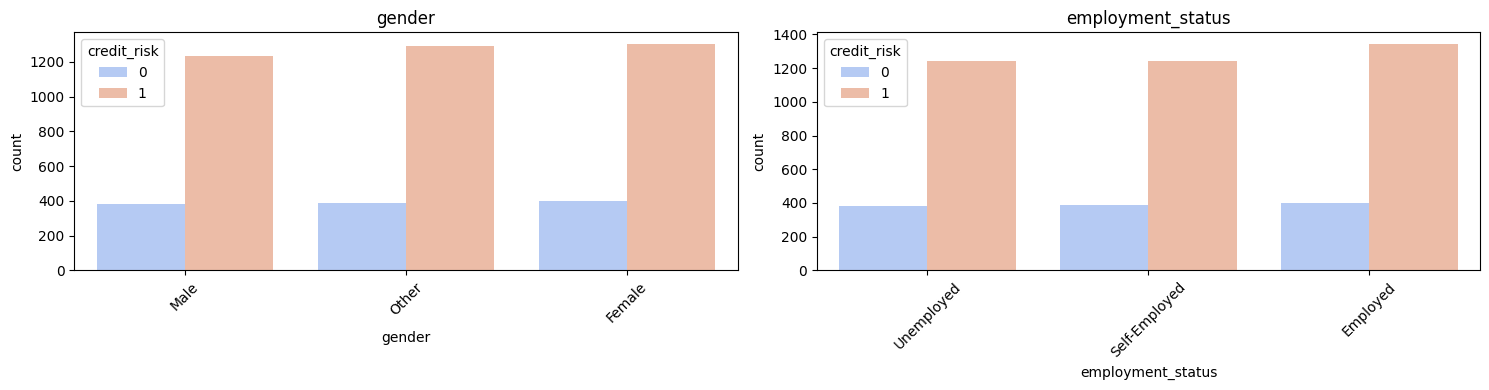

In [91]:
subplot_count = len(cat)
rows = (subplot_count + 1) // 2
col = 2

fig,axes = plt.subplots(rows,col,figsize=(15,rows*4))
axes = axes.flatten()

for i,col in enumerate(cat):
    value_counts = df[col].value_counts()
    sns.countplot(
        data=df,
        x=col,
        hue='credit_risk',
        ax=axes[i],
        palette='coolwarm'
    )
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

# Remove extra empty plots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Feature Engineering

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 5000 non-null   object 
 1   age                         5000 non-null   int64  
 2   gender                      5000 non-null   object 
 3   employment_status           5000 non-null   object 
 4   annual_income               5000 non-null   float64
 5   account_age_months          5000 non-null   int64  
 6   avg_monthly_balance         5000 non-null   float64
 7   num_deposits_per_month      5000 non-null   int64  
 8   avg_deposit_amount          5000 non-null   float64
 9   debit_card_usage_frequency  5000 non-null   int64  
 10  debit_card_spending         5000 non-null   float64
 11  mobile_banking_logins       5000 non-null   int64  
 12  online_transfer_frequency   5000 non-null   int64  
 13  atm_withdrawal_frequency    5000 

In [93]:
# =========================
# 1. Debt-to-Income Ratio
# =========================
# Financial stress indicator

df['debt_to_income_ratio'] = (
    df['total_outstanding_debt'] / (df['annual_income'] + 1)
)

# =========================
# 2. Loan-to-Income Ratio
# =========================
# Measures affordability of requested loan

df['loan_to_income_ratio'] = (
    df['loan_application_amount'] / (df['annual_income'] + 1)
)

# =========================
# 3. Debt Per Loan
# =========================
# Average debt burden per active loan

df['debt_per_loan'] = (
    df['total_outstanding_debt'] / (df['num_open_loans'] + 1)
)

# =========================
# 4. Late Payment Ratio
# =========================
# Captures repayment behavior

df['late_payment_ratio'] = (
    df['late_payment_count'] / (df['num_open_loans'] + 1)
)

# =========================
# 5. Spending-to-Balance Ratio
# =========================
# Indicates aggressive spending behavior

df['spending_balance_ratio'] = (
    df['debit_card_spending'] / (df['avg_monthly_balance'] + 1)
)

# =========================
# 6. Digital Activity Score
# =========================
# Customer engagement indicator

df['digital_activity_score'] = (
    df['mobile_banking_logins'] +
    df['online_transfer_frequency']
)

# =========================
# 7. Total Transaction Activity
# =========================
# Overall banking activity

df['total_transaction_activity'] = (
    df['num_deposits_per_month'] +
    df['debit_card_usage_frequency'] +
    df['atm_withdrawal_frequency']
)

# =========================
# 8. Account Age in Years
# =========================
# Customer stability indicator

df['account_age_years'] = (
    df['account_age_months'] / 12
)

# =========================
# 9. Credit Score Buckets
# =========================
# Common financial risk segmentation

df['credit_score_band'] = pd.cut(
    df['credit_score'],
    bins=[300, 580, 670, 740, 800, 900],
    labels=['Poor', 'Fair', 'Good', 'Very_Good', 'Excellent']
)

# =========================
# 10. Income-Credit Interaction
# =========================
# Combines earning power with creditworthiness

df['income_credit_interaction'] = (
    df['annual_income'] * df['credit_score']
)



In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 32 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   customer_id                 5000 non-null   object  
 1   age                         5000 non-null   int64   
 2   gender                      5000 non-null   object  
 3   employment_status           5000 non-null   object  
 4   annual_income               5000 non-null   float64 
 5   account_age_months          5000 non-null   int64   
 6   avg_monthly_balance         5000 non-null   float64 
 7   num_deposits_per_month      5000 non-null   int64   
 8   avg_deposit_amount          5000 non-null   float64 
 9   debit_card_usage_frequency  5000 non-null   int64   
 10  debit_card_spending         5000 non-null   float64 
 11  mobile_banking_logins       5000 non-null   int64   
 12  online_transfer_frequency   5000 non-null   int64   
 13  atm_withdrawal_fre

In [95]:
# removing customer id form  the dataset and splitting the numerical and categorical data
df = df.drop(columns=['customer_id'],axis=1)
numerical = df.select_dtypes(include=['int64']).columns
categorical = df.select_dtypes(include=['object','category']).columns
print(f"Shape of data: {df.shape}")
print(f"Numerical data ({len(numerical)}): \n{numerical}")
print(f"Categorical data ({len(categorical)}): \n{categorical}")

Shape of data: (5000, 31)
Numerical data (15): 
Index(['age', 'account_age_months', 'num_deposits_per_month',
       'debit_card_usage_frequency', 'mobile_banking_logins',
       'online_transfer_frequency', 'atm_withdrawal_frequency', 'credit_score',
       'num_open_loans', 'late_payment_count', 'loan_default_history',
       'fraud_flag', 'credit_risk', 'digital_activity_score',
       'total_transaction_activity'],
      dtype='object')
Categorical data (3): 
Index(['gender', 'employment_status', 'credit_score_band'], dtype='object')


In [96]:
# Splitting the data for encoding
from sklearn.model_selection import train_test_split

y = df['credit_risk']
X = df.drop(columns=['credit_risk'],axis = 1)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

print(f"Shape of Data:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

Shape of Data:
X_train: (3750, 30)
y_train: (3750,)
X_test: (1250, 30)
y_test: (1250,)


In [123]:
# encoding the data
from sklearn.preprocessing import OneHotEncoder
import category_encoders as ce
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# numerical and categorical columns
num_col = X_train.select_dtypes(include=['int64','float64']).columns
cat_col = X_train.select_dtypes(include=['object','category']).columns

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

encoder = OneHotEncoder(handle_unknown='ignore')

num_pipe = Pipeline(steps=[
    ('imputer',num_imputer)
])

cat_pipe = Pipeline(steps=[
    ('imputer',cat_imputer),
    ('encoder',encoder)
])

preprocessor = ColumnTransformer(
    transformers=[
        ('numerical',num_pipe,num_col),
        ('categorical',cat_pipe,cat_col)
    ]
)


In [127]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

classifier = LogisticRegression(max_iter=1000)
model = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('classifier',classifier)
])

model.fit(X_train,y_train)
y_pred = model.predict(X_test)

print(classification_report(y_true=y_test,y_pred=y_pred))


              precision    recall  f1-score   support

           0       0.39      0.20      0.27       291
           1       0.79      0.90      0.84       959

    accuracy                           0.74      1250
   macro avg       0.59      0.55      0.55      1250
weighted avg       0.69      0.74      0.71      1250

